In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df =pd.read_csv('/content/data.csv')
df.head()
#

,Unnamed: 0.1,Unnamed: 0,brand,name,price,spec_rating,processor,CPU,Ram,Ram_type,ROM,ROM_type,GPU,display_size,resolution_width,resolution_height,OS,warranty
0,0,0,HP,Victus 15-fb0157AX Gaming Laptop,49900,73.000000,5th Gen AMD Ryzen 5 5600H,"Hexa Core, 12 Threads",8GB,DDR4,512GB,SSD,4GB AMD Radeon RX 6500M,15.6,1920.0,1080.0,Windows 11 OS,1
1,1,1,HP,15s-fq5007TU Laptop,39900,60.000000,12th Gen Intel Core i3 1215U,"Hexa Core (2P + 4E), 8 Threads",8GB,DDR4,512GB,SSD,Intel UHD Graphics,15.6,1920.0,1080.0,Windows 11 OS,1
2,2,2,Acer,One 14 Z8-415 Laptop,26990,69.323529,11th Gen Intel Core i3 1115G4,"Dual Core, 4 Threads",8GB,DDR4,512GB,SSD,Intel Iris Xe Graphics,14.0,1920.0,1080.0,Windows 11 OS,1
3,3,3,Lenovo,Yoga Slim 6 14IAP8 82WU0095IN Laptop,59729,66.000000,12th Gen Intel Core i5 1240P,"12 Cores (4P + 8E), 16 Threads",16GB,LPDDR5,512GB,SSD,Intel Integrated Iris Xe,14.0,2240.0,1400.0,Windows 11 OS,1
4,4,4,Apple,MacBook Air 2020 MGND3HN Laptop,69990,69.323529,Apple M1,Octa Core (4P + 4E),8GB,DDR4,256GB,SSD,Apple M1 Integrated Graphics,13.3,2560.0,1600.0,Mac OS,1


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 893 entries, 0 to 892
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0.1       893 non-null    int64  
 1   Unnamed: 0         893 non-null    int64  
 2   brand              893 non-null    object 
 3   name               893 non-null    object 
 4   price              893 non-null    int64  
 5   spec_rating        893 non-null    float64
 6   processor          893 non-null    object 
 7   CPU                893 non-null    object 
 8   Ram                893 non-null    object 
 9   Ram_type           893 non-null    object 
 10  ROM                893 non-null    object 
 11  ROM_type           893 non-null    object 
 12  GPU                893 non-null    object 
 13  display_size       893 non-null    float64
 14  resolution_width   893 non-null    float64
 15  resolution_height  893 non-null    float64
 16  OS                 893 non

In [ ]:
df.shape

(893, 16)

In [ ]:
print(f"The Laptop Price Dataset has {df.shape[0]} rows and {df.shape[1]} columns")


The Laptop Price Dataset has 893 rows and 18 columns


In [ ]:
df.isnull().sum()


,0
Unnamed: 0.1,0
Unnamed: 0,0
brand,0
name,0
price,0
spec_rating,0
processor,0
CPU,0
Ram,0
Ram_type,0


In [ ]:
df.drop(['Unnamed: 0.1', 'Unnamed: 0'], axis=1, inplace=True)


In [ ]:
df.describe()


,price,spec_rating,display_size,resolution_width,resolution_height,warranty
count,893.000000,893.000000,893.000000,893.000000,893.000000,893.000000
mean,79907.409854,69.379026,15.173751,2035.393057,1218.324748,1.079507
std,60880.043823,5.541555,0.939095,426.076009,326.756883,0.326956
min,9999.000000,60.000000,11.600000,1080.000000,768.000000,0.000000
25%,44500.000000,66.000000,14.000000,1920.000000,1080.000000,1.000000
50%,61990.000000,69.323529,15.600000,1920.000000,1080.000000,1.000000
75%,90990.000000,71.000000,15.600000,1920.000000,1200.000000,1.000000
max,450039.000000,89.000000,18.000000,3840.000000,3456.000000,3.000000


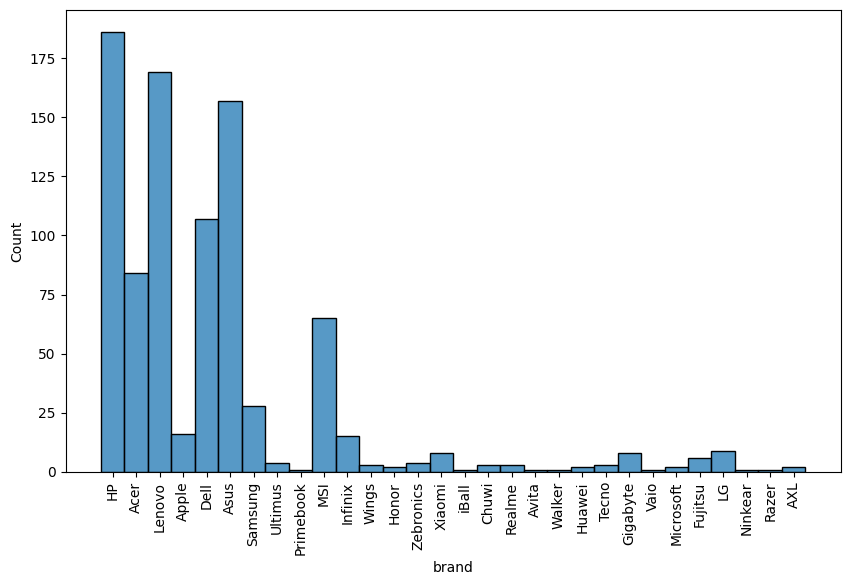

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.histplot(df['brand'], bins=20)
plt.xticks(rotation=90)
plt.show()

In [ ]:
df.corr(numeric_only=True)

,price,spec_rating,display_size,resolution_width,resolution_height,warranty
price,1.000000,0.546391,0.233815,0.586042,0.604748,0.117101
spec_rating,0.546391,1.000000,0.274206,0.337649,0.328525,0.109501
display_size,0.233815,0.274206,1.000000,0.125088,0.029692,0.041126
resolution_width,0.586042,0.337649,0.125088,1.000000,0.731557,0.024199
resolution_height,0.604748,0.328525,0.029692,0.731557,1.000000,-0.001060
warranty,0.117101,0.109501,0.041126,0.024199,-0.001060,1.000000


In [ ]:
plt = px.histogram(df, x="brand", title="Brand Distribution",
                   color="brand", color_discrete_sequence=px.colors.qualitative.Pastel)
plt.show()

In [ ]:
df.describe(exclude=np.number)


,brand,name,processor,CPU,Ram,Ram_type,ROM,ROM_type,GPU,OS
count,893,893,893,893,893,893,893,893,893,893
unique,30,815,184,29,7,12,7,2,134,14
top,HP,Inspiron 3525 Laptop,12th Gen Intel Core i5 1235U,"Quad Core, 8 Threads",16GB,DDR4,512GB,SSD,Intel Iris Xe Graphics,Windows 11 OS
freq,186,4,49,130,456,499,634,872,107,782


In [ ]:
df['brand'].unique()

array(['HP', 'Acer', 'Lenovo', 'Apple', 'Dell', 'Asus', 'Samsung',
       'Ultimus', 'Primebook', 'MSI', 'Infinix', 'Wings', 'Honor',
       'Zebronics', 'Xiaomi', 'iBall', 'Chuwi', 'Realme', 'Avita',
       'Walker', 'Huawei', 'Tecno', 'Gigabyte', 'Vaio', 'Microsoft',
       'Fujitsu', 'LG', 'Ninkear', 'Razer', 'AXL'], dtype=object)

In [ ]:
df['brand'].count()

np.int64(893)

In [ ]:
brand = df['brand'].value_counts().sort_values(ascending=False)[:10]
brand

,count
brand,
HP,186
Lenovo,169
Asus,157
Dell,107
Acer,84
MSI,65
Samsung,28
Apple,16
Infinix,15


In [ ]:
print(f"The highest popular brand in the market is '{brand.idxmax()}'")


The highest popular brand in the market is 'HP'


In [ ]:
fig = px.bar(brand,
             color=brand.index,
             text_auto=True,
             labels={'index':'Name of Brand'},
             title='Top 10 Brand in The World')
fig.show()

In [ ]:
price_brand = df.groupby('brand')['price'].mean().sort_values(ascending=False)[:10]

price_brand

,price
brand,
Razer,199990.000000
Apple,174230.875000
Gigabyte,133279.125000
LG,128618.444444
Samsung,117512.142857
MSI,100849.630769
Dell,91150.934579
Fujitsu,81656.666667
HP,80872.473118


In [ ]:
print(f"Most expensive brand in the market '{price_brand.idxmax()}'")


Most expensive brand in the market 'Razer'


In [ ]:
fig = px.bar(price_brand,
             color=price_brand.index,
             labels={'brand':'Name Of Brand','value':'AVG of Price'},
             text_auto=True,
             title='Is Brand affect on Price ?')
fig.show()

In [ ]:
processor = df['processor'].value_counts()[:25]
print(f"Top Processor Use in Labtops is '{processor.idxmax()}' with '{processor.max()}'")

Top Processor Use in Labtops is '12th Gen Intel Core i5 1235U' with '49'


In [ ]:
fig = px.bar(processor,
             color=processor.index,
             labels={'value':'Numebr','index':'Name of Processor'},
             title='Top 25 Processors Popular',
             orientation='h')
fig.show()

In [ ]:
cpu = df['CPU'].value_counts()[:20]
print(f"Top Processor Use in Labtops is '{cpu.idxmax()}' with '{cpu.max()}'")

Top Processor Use in Labtops is 'Quad Core, 8 Threads' with '130'


In [ ]:
fig = px.bar(cpu,
             color=cpu.index,
             labels={'value':'Numebr','index':'Name of CPU'},
             title='Top 20 CPU Popular',
             orientation='h')
fig.show()

In [ ]:
df.head()

,brand,name,price,spec_rating,processor,CPU,Ram,Ram_type,ROM,ROM_type,GPU,display_size,resolution_width,resolution_height,OS,warranty
0,HP,Victus 15-fb0157AX Gaming Laptop,49900,73.000000,5th Gen AMD Ryzen 5 5600H,"Hexa Core, 12 Threads",8GB,DDR4,512GB,SSD,4GB AMD Radeon RX 6500M,15.6,1920.0,1080.0,Windows 11 OS,1
1,HP,15s-fq5007TU Laptop,39900,60.000000,12th Gen Intel Core i3 1215U,"Hexa Core (2P + 4E), 8 Threads",8GB,DDR4,512GB,SSD,Intel UHD Graphics,15.6,1920.0,1080.0,Windows 11 OS,1
2,Acer,One 14 Z8-415 Laptop,26990,69.323529,11th Gen Intel Core i3 1115G4,"Dual Core, 4 Threads",8GB,DDR4,512GB,SSD,Intel Iris Xe Graphics,14.0,1920.0,1080.0,Windows 11 OS,1
3,Lenovo,Yoga Slim 6 14IAP8 82WU0095IN Laptop,59729,66.000000,12th Gen Intel Core i5 1240P,"12 Cores (4P + 8E), 16 Threads",16GB,LPDDR5,512GB,SSD,Intel Integrated Iris Xe,14.0,2240.0,1400.0,Windows 11 OS,1
4,Apple,MacBook Air 2020 MGND3HN Laptop,69990,69.323529,Apple M1,Octa Core (4P + 4E),8GB,DDR4,256GB,SSD,Apple M1 Integrated Graphics,13.3,2560.0,1600.0,Mac OS,1


In [ ]:
ram = df['Ram'].value_counts()
print(f"Most RAM size Use in laptops is '{ram.idxmax()}' with '{ram.max()}'")
ram

Most RAM size Use in laptops is '16GB' with '456'


,count
Ram,
16GB,456
8GB,369
32GB,40
4GB,22
64GB,3
12GB,2
2GB,1


In [ ]:
fig = px.pie(values=ram,
             names=['16 GB','8 GB','32 GB','4 GB','64 GB','12 GB','2 GB'],
             title='RAM Size in Labtops'

).update_traces(textinfo='label+percent')
fig.show()

In [ ]:
ram_type = df['Ram_type'].value_counts()
print(f"Most Type of RAM is Used in laptop is '{ram_type.idxmax()}' with '{ram_type.max()}'")

Most Type of RAM is Used in laptop is 'DDR4' with '499'


In [ ]:
fig = px.bar(ram_type,
             orientation='h',
             color=ram_type.index,
             text=ram_type.values,
             labels={'index':'RAM Type'},
             title='Most Type of RAM is Used in laptop'
)
fig.show()

# Model Traning

In [ ]:
df.head()

,brand,name,price,spec_rating,processor,CPU,Ram,Ram_type,ROM,ROM_type,GPU,display_size,resolution_width,resolution_height,OS,warranty
0,HP,Victus 15-fb0157AX Gaming Laptop,49900,73.000000,5th Gen AMD Ryzen 5 5600H,"Hexa Core, 12 Threads",8,DDR4,512GB,SSD,4GB AMD Radeon RX 6500M,15.6,1920.0,1080.0,Windows 11 OS,1
1,HP,15s-fq5007TU Laptop,39900,60.000000,12th Gen Intel Core i3 1215U,"Hexa Core (2P + 4E), 8 Threads",8,DDR4,512GB,SSD,Intel UHD Graphics,15.6,1920.0,1080.0,Windows 11 OS,1
2,Acer,One 14 Z8-415 Laptop,26990,69.323529,11th Gen Intel Core i3 1115G4,"Dual Core, 4 Threads",8,DDR4,512GB,SSD,Intel Iris Xe Graphics,14.0,1920.0,1080.0,Windows 11 OS,1
3,Lenovo,Yoga Slim 6 14IAP8 82WU0095IN Laptop,59729,66.000000,12th Gen Intel Core i5 1240P,"12 Cores (4P + 8E), 16 Threads",16,LPDDR5,512GB,SSD,Intel Integrated Iris Xe,14.0,2240.0,1400.0,Windows 11 OS,1
4,Apple,MacBook Air 2020 MGND3HN Laptop,69990,69.323529,Apple M1,Octa Core (4P + 4E),8,DDR4,256GB,SSD,Apple M1 Integrated Graphics,13.3,2560.0,1600.0,Mac OS,1


In [ ]:
# Define the columns
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_columns.remove('price')  # Exclude the target column from numerical columns
numerical_columns.remove('spec_rating') # We Don't need this column as the ratings are based on the RAM, ROM, CUP, GPU etc.

# Data Cleaning and Encoding

In [ ]:
df['Ram'] = df['Ram'].str.replace('GB', '').astype('int')


In [ ]:
df['ROM'] = df['ROM'].str.replace('GB', '').str.replace('TB', '000')
df['ROM'] = df['ROM'].astype('int')

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {} # Dictionary to store individual encoders

categorical_cols_to_encode = ['brand', 'processor', 'CPU', 'GPU', 'OS', 'Ram_type', 'ROM_type']

for col in categorical_cols_to_encode:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [ ]:
df.drop(columns=['name'], inplace=True)


KeyError: "['name'] not found in axis"

In [ ]:
df.head()

,brand,price,spec_rating,processor,CPU,Ram,Ram_type,ROM,ROM_type,GPU,display_size,resolution_width,resolution_height,OS,warranty
0,9,49900,73.000000,105,19,8,2,512,1,19,15.6,1920.0,1080.0,12,1
1,9,39900,60.000000,34,18,8,2,512,1,126,15.6,1920.0,1080.0,12,1
2,1,26990,69.323529,15,17,8,2,512,1,123,14.0,1920.0,1080.0,12,1
3,14,59729,66.000000,39,6,16,8,512,1,111,14.0,2240.0,1400.0,12,1
4,2,69990,69.323529,160,21,8,2,256,1,91,13.3,2560.0,1600.0,7,1


In [ ]:
import pickle

with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f) # Save the dictionary of encoders

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression Model¶


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression

In [ ]:
LR_model = LinearRegression()


In [ ]:
LR_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
import numpy as np
y_pred = LR_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 19018.801431281936
RMSE: 27520.109830161633
R2 Score: 0.7789801580564768


In [ ]:
import pickle

with open("LR_model.pkl", "wb") as f:
    pickle.dump(LR_model, f)

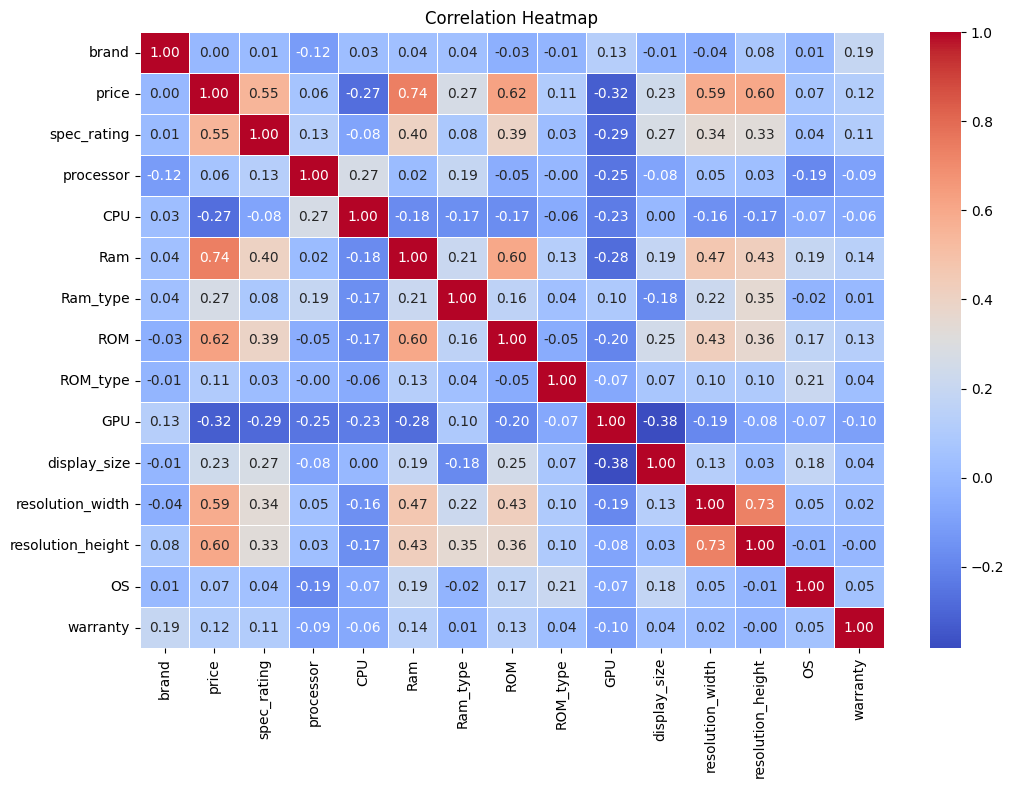

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 94.7 MB/s eta 0:00:00


In [ ]:
import streamlit as st
import pickle
import pandas as pd

# Load the trained model
with open('LR_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Load the dictionary of label encoders
with open('label_encoders.pkl', 'rb') as f:
    label_encoders = pickle.load(f) # Load the dictionary

st.title('Laptop Price Prediction App')
st.write('Enter the details of the laptop to predict its price.')

# Input fields for features (adjust based on your 'X' DataFrame columns)
# Use specific encoders for each column
brand_le = label_encoders['brand']
brand = st.selectbox('Brand', brand_le.inverse_transform(df['brand'].unique())) # Use brand_le

spec_rating = st.slider('Specification Rating', 60.0, 90.0, 75.0)

processor_le = label_encoders['processor']
processor = st.selectbox('Processor', processor_le.inverse_transform(df['processor'].unique()))

cpu_le = label_encoders['CPU']
CPU = st.selectbox('CPU', cpu_le.inverse_transform(df['CPU'].unique()))

Ram = st.selectbox('RAM (GB)', [2, 4, 8, 12, 16, 32, 64])

ram_type_le = label_encoders['Ram_type']
Ram_type = st.selectbox('RAM Type', ram_type_le.inverse_transform(df['Ram_type'].unique()))

ROM = st.selectbox('ROM (GB)', [256, 512, 1000, 2000])

rom_type_le = label_encoders['ROM_type']
ROM_type = st.selectbox('ROM Type', rom_type_le.inverse_transform(df['ROM_type'].unique()))

gpu_le = label_encoders['GPU']
GPU = st.selectbox('GPU', gpu_le.inverse_transform(df['GPU'].unique()))

display_size = st.slider('Display Size (inches)', 11.0, 18.0, 15.6)
resolution_width = st.slider('Resolution Width', 1080, 3840, 1920)
resolution_height = st.slider('Resolution Height', 768, 3456, 1080)

os_le = label_encoders['OS']
OS = st.selectbox('Operating System', os_le.inverse_transform(df['OS'].unique()))

warranty = st.selectbox('Warranty (Years)', [0, 1, 2, 3])

if st.button('Predict Price'):
    # Encode categorical inputs using the loaded LabelEncoder
    encoded_brand = brand_le.transform([brand])[0]
    encoded_processor = processor_le.transform([processor])[0]
    encoded_CPU = cpu_le.transform([CPU])[0]
    encoded_Ram_type = ram_type_le.transform([Ram_type])[0]
    encoded_ROM_type = rom_type_le.transform([ROM_type])[0]
    encoded_GPU = gpu_le.transform([GPU])[0]
    encoded_OS = os_le.transform([OS])[0]

    # Create a DataFrame for prediction
    input_data = pd.DataFrame([[encoded_brand, spec_rating, encoded_processor, encoded_CPU, Ram, encoded_Ram_type, ROM, encoded_ROM_type, encoded_GPU, display_size, resolution_width, resolution_height, encoded_OS, warranty]],
                                columns=X.columns) # X is from the notebook kernel state

    # Make prediction
    prediction = model.predict(input_data)[0]
    st.success(f'Predicted Laptop Price: ₹{prediction:,.2f}')

2026-05-12 08:44:01.777 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 08:44:01.778 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 08:44:01.779 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 08:44:01.781 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 08:44:01.783 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 08:44:01.784 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 08:44:01.787 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 08:44:01.788 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [ ]:
%%writefile app.py
import streamlit as st
import pickle
import pandas as pd

# Load the trained model
with open('LR_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Load the dictionary of label encoders
with open('label_encoders.pkl', 'rb') as f:
    label_encoders = pickle.load(f) # Load the dictionary

st.title('Laptop Price Prediction App')
st.write('Enter the details of the laptop to predict its price.')

# Input fields for features (adjust based on your 'X' DataFrame columns)
# Use specific encoders for each column

# Create a dummy DataFrame to get unique values for inverse_transform,
# as the original `df` might not be available when running the Streamlit app directly.
# This assumes the label_encoders were fitted on the complete original df.
# For a robust solution, you'd typically save the inverse_transform mappings or use a fixed list of options.
# For now, we'll recreate a temporary df to get the original categories.

# NOTE: In a real deployment, you would not rely on 'df' being in scope.
# Instead, you would load the unique categories that were used during fitting
# and pass them to the selectbox. For this example, we'll assume 'df' is available for options.
# In a real Streamlit app, you might hardcode the options or load them from a saved file.

# Example of how to get the options for brand, if df is not globally available:
# brand_options = label_encoders['brand'].inverse_transform(range(len(label_encoders['brand'].classes_)))

# Using existing `df` from the notebook's kernel state for simplicity in Colab context.
# In a standalone app.py, you would need to load `df` or save/load the unique categories separately.

brand_le = label_encoders['brand']
brand = st.selectbox('Brand', brand_le.inverse_transform(range(len(brand_le.classes_))))

spec_rating = st.slider('Specification Rating', 60.0, 90.0, 75.0)

processor_le = label_encoders['processor']
processor = st.selectbox('Processor', processor_le.inverse_transform(range(len(processor_le.classes_))))

cpu_le = label_encoders['CPU']
CPU = st.selectbox('CPU', cpu_le.inverse_transform(range(len(cpu_le.classes_))))

Ram = st.selectbox('RAM (GB)', [2, 4, 8, 12, 16, 32, 64])

ram_type_le = label_encoders['Ram_type']
Ram_type = st.selectbox('RAM Type', ram_type_le.inverse_transform(range(len(ram_type_le.classes_))))

ROM = st.selectbox('ROM (GB)', [256, 512, 1000, 2000])

rom_type_le = label_encoders['ROM_type']
ROM_type = st.selectbox('ROM Type', rom_type_le.inverse_transform(range(len(rom_type_le.classes_))))

gpu_le = label_encoders['GPU']
GPU = st.selectbox('GPU', gpu_le.inverse_transform(range(len(gpu_le.classes_))))

display_size = st.slider('Display Size (inches)', 11.0, 18.0, 15.6)
resolution_width = st.slider('Resolution Width', 1080, 3840, 1920)
resolution_height = st.slider('Resolution Height', 768, 3456, 1080)

os_le = label_encoders['OS']
OS = st.selectbox('Operating System', os_le.inverse_transform(range(len(os_le.classes_))))

warranty = st.selectbox('Warranty (Years)', [0, 1, 2, 3])

if st.button('Predict Price'):
    # Encode categorical inputs using the loaded LabelEncoder
    encoded_brand = brand_le.transform([brand])[0]
    encoded_processor = processor_le.transform([processor])[0]
    encoded_CPU = cpu_le.transform([CPU])[0]
    encoded_Ram_type = ram_type_le.transform([Ram_type])[0]
    encoded_ROM_type = rom_type_le.transform([ROM_type])[0]
    encoded_GPU = gpu_le.transform([GPU])[0]
    encoded_OS = os_le.transform([OS])[0]

    # Create a DataFrame for prediction
    input_data = pd.DataFrame([[
        encoded_brand, spec_rating, encoded_processor, encoded_CPU, Ram,
        encoded_Ram_type, ROM, encoded_ROM_type, encoded_GPU, display_size,
        resolution_width, resolution_height, encoded_OS, warranty
    ]],
    columns=['brand', 'spec_rating', 'processor', 'CPU', 'Ram', 'Ram_type', 'ROM',
             'ROM_type', 'GPU', 'display_size', 'resolution_width',
             'resolution_height', 'OS', 'warranty'])

    # Make prediction
    prediction = model.predict(input_data)[0]
    st.success(f'Predicted Laptop Price: ₹{prediction:,.2f}')

Writing app.py


In [ ]:
%%writefile requirements.txt
pandas
numpy
matplotlib
seaborn
scikit-learn
plotly
streamlit


In [ ]:
# Laptop Price Prediction Project

This project aims to predict laptop prices based on various specifications using a Linear Regression model.

## Table of Contents
1.  [Overview](#overview)
2.  [Data Source](#data-source)
3.  [Exploratory Data Analysis (EDA)](#exploratory-data-analysis-eda)
4.  [Data Preprocessing](#data-preprocessing)
5.  [Model Training & Evaluation](#model-training--evaluation)
6.  [Streamlit Deployment](#streamlit-deployment)
7.  [Requirements](#requirements)

## Overview
This notebook performs an end-to-end machine learning project for laptop price prediction. It covers data loading, extensive exploratory data analysis, data cleaning and preprocessing, training a Linear Regression model, evaluating its performance, and preparing a Streamlit application for deployment.

## Data Source
The dataset used is `data.csv`, which contains various attributes of laptops including brand, name, price, specifications, processor details, RAM, ROM, GPU, display size, resolution, operating system, and warranty information.

## Exploratory Data Analysis (EDA)
- Initial data inspection using `df.info()`, `df.shape`, and `df.isnull().sum()`.
- Dropped irrelevant `Unnamed` columns.
- Generated descriptive statistics for numerical and categorical features.
- Visualized distributions of key categorical features like `brand`, `processor`, `CPU`, `RAM`, `RAM_type`, and `GPU` using histograms, bar charts, and pie charts.
- Analyzed the correlation between numerical features with a heatmap.

## Data Preprocessing
- Cleaned and converted 'Ram' and 'ROM' columns to numerical types (e.g., '8GB' to `8`, '512GB' to `512`, '1TB' to `1000`).
- Dropped the 'name' column as it was highly unique and not suitable for direct use in the model.
- Applied `LabelEncoder` to all significant categorical features (`brand`, `processor`, `CPU`, `GPU`, `OS`, `Ram_type`, `ROM_type`). Each encoder was saved individually to ensure proper inverse transformation during deployment.
- Split the data into features (X) and target (y - 'price'), followed by an 80/20 train-test split.

## Model Training & Evaluation
- A `LinearRegression` model was chosen for predicting laptop prices.
- The model was trained on the preprocessed training data.
- Model performance was evaluated using:
    - **Mean Absolute Error (MAE):** Approximately 19,018
    - **Root Mean Squared Error (RMSE):** Approximately 27,520
    - **R2 Score:** Approximately 0.779
- The trained model and the dictionary of `LabelEncoder` objects were saved using `pickle` for later deployment.

## Streamlit Deployment
- A Streamlit application (`app.py`) was created to provide an interactive interface for predicting laptop prices.
- The application loads the saved Linear Regression model and the label encoders.
- Users can input various laptop specifications through select boxes and sliders.
- The app then uses the trained model to predict and display the estimated laptop price.

## Requirements
The necessary Python packages for running this project and the Streamlit app are listed in `requirements.txt`.

In [1]:
categorical_cols_to_encode = ['brand', 'processor', 'CPU', 'GPU', 'OS', 'Ram_type', 'ROM_type']

In [2]:
%%writefile app.py
import streamlit as st
import pickle
import pandas as pd

# Load the trained model
with open('LR_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Load the dictionary of label encoders
with open('label_encoders.pkl', 'rb') as f:
    label_encoders = pickle.load(f) # Load the dictionary

st.title('Laptop Price Prediction App')
st.write('Enter the details of the laptop to predict its price.')

# Input fields for features (adjust based on your 'X' DataFrame columns)
# Use specific encoders for each column

# Create a dummy DataFrame to get unique values for inverse_transform,
# as the original `df` might not be available when running the Streamlit app directly.
# This assumes the label_encoders were fitted on the complete original df.
# For a robust solution, you'd typically save the inverse_transform mappings or use a fixed list of options.

# Using the `classes_` attribute of the LabelEncoder to get all unique categories
brand_le = label_encoders['brand']
brand = st.selectbox('Brand', brand_le.inverse_transform(range(len(brand_le.classes_))))

spec_rating = st.slider('Specification Rating', 60.0, 90.0, 75.0)

processor_le = label_encoders['processor']
processor = st.selectbox('Processor', processor_le.inverse_transform(range(len(processor_le.classes_))))

cpu_le = label_encoders['CPU']
CPU = st.selectbox('CPU', cpu_le.inverse_transform(range(len(cpu_le.classes_))))

Ram = st.selectbox('RAM (GB)', [2, 4, 8, 12, 16, 32, 64])

ram_type_le = label_encoders['Ram_type']
Ram_type = st.selectbox('RAM Type', ram_type_le.inverse_transform(range(len(ram_type_le.classes_))))

ROM = st.selectbox('ROM (GB)', [256, 512, 1000, 2000])

rom_type_le = label_encoders['ROM_type']
ROM_type = st.selectbox('ROM Type', rom_type_le.inverse_transform(range(len(rom_type_le.classes_))))

gpu_le = label_encoders['GPU']
GPU = st.selectbox('GPU', gpu_le.inverse_transform(range(len(gpu_le.classes_))))

display_size = st.slider('Display Size (inches)', 11.0, 18.0, 15.6)
resolution_width = st.slider('Resolution Width', 1080, 3840, 1920)
resolution_height = st.slider('Resolution Height', 768, 3456, 1080)

os_le = label_encoders['OS']
OS = st.selectbox('Operating System', os_le.inverse_transform(range(len(os_le.classes_))))

warranty = st.selectbox('Warranty (Years)', [0, 1, 2, 3])

if st.button('Predict Price'):
    # Encode categorical inputs using the loaded LabelEncoder
    encoded_brand = brand_le.transform([brand])[0]
    encoded_processor = processor_le.transform([processor])[0]
    encoded_CPU = cpu_le.transform([CPU])[0]
    encoded_Ram_type = ram_type_le.transform([Ram_type])[0]
    encoded_ROM_type = rom_type_le.transform([ROM_type])[0]
    encoded_GPU = gpu_le.transform([GPU])[0]
    encoded_OS = os_le.transform([OS])[0]

    # Create a DataFrame for prediction
    input_data = pd.DataFrame([[
        encoded_brand, spec_rating, encoded_processor, encoded_CPU, Ram,
        encoded_Ram_type, ROM, encoded_ROM_type, encoded_GPU, display_size,
        resolution_width, resolution_height, encoded_OS, warranty
    ]],
    columns=['brand', 'spec_rating', 'processor', 'CPU', 'Ram', 'Ram_type', 'ROM',
             'ROM_type', 'GPU', 'display_size', 'resolution_width',
             'resolution_height', 'OS', 'warranty'])

    # Make prediction
    prediction = model.predict(input_data)[0]
    st.success(f'Predicted Laptop Price: ₹{prediction:,.2f}')

Writing app.py
